# Applying Linear Regression Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
# 1. Load the transformed dataset
# Ensure 'df_transformed.csv' is in the same directory as your notebook
df = pd.read_csv('df_filtered2.csv')

# 2. Define features (X) and target (y)
# We are predicting 'popularity' using all other available columns
target = 'popularity'
X = df.drop(columns=[target])
y = df[target]

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = lr_model.predict(X_test)

# 6. Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Linear Regression Performance ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

--- Linear Regression Performance ---
Mean Squared Error (MSE): 0.0060
Mean Absolute Error (MAE): 0.0607
R-squared (R2): 0.4847


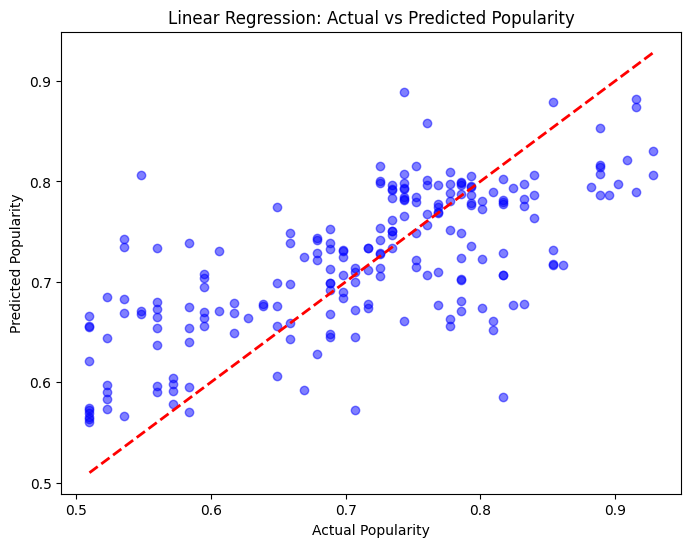

In [3]:
# 7. Visualize: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
# Add a diagonal line for reference (perfect prediction)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Linear Regression: Actual vs Predicted Popularity')
plt.show()

In [4]:
# 8. Inspect Feature Importance (Coefficients)
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print("\n--- Feature Coefficients (Influence on Popularity) ---")
print(coefficients)


--- Feature Coefficients (Influence on Popularity) ---
                  Feature  Coefficient
10               explicit     0.073719
15        track_genre_pop     0.070515
5                  energy     0.001827
12                   mode     0.001507
9                   tempo     0.001042
11                    key     0.000952
4            danceability     0.000649
7        instrumentalness     0.000078
8                liveness    -0.000271
2                loudness    -0.000325
6             speechiness    -0.001435
0                 valence    -0.003750
13         time_signature    -0.009617
1            acousticness    -0.010392
3             duration_ms    -0.013487
14  track_genre_indie-pop    -0.031645
17  track_genre_synth-pop    -0.068922
16      track_genre_r-n-b    -0.145848
